In [55]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [56]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [57]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

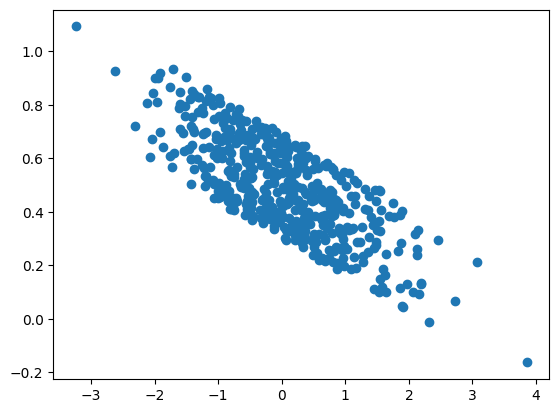

In [58]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [59]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


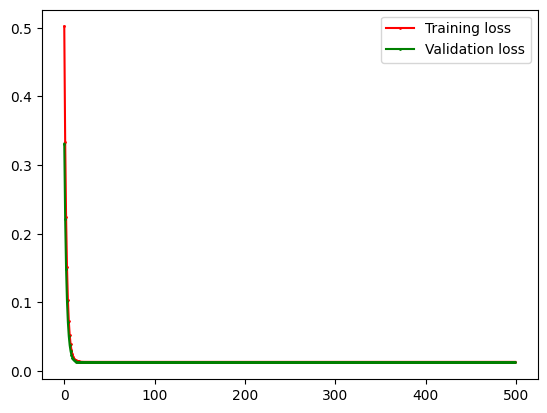

In [60]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.1,n_iteration =500,val_ratio=0.2)

In [61]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [62]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013356333749635324,
 'MAE': 0.10095600779556413,
 'RMSE': np.float64(0.11556960564800471),
 'R-squared': 0.5689641130867413}

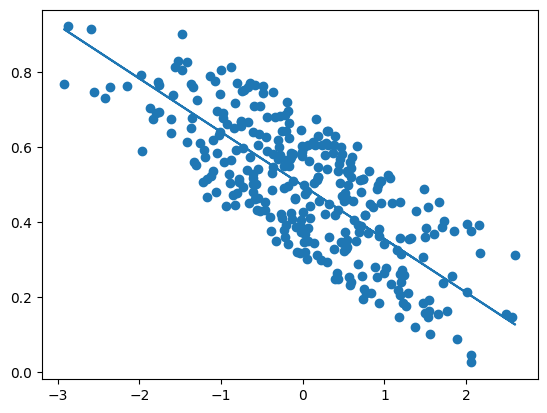

In [63]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()